# Vergleich: MixUp-Regressor vs. Synthetischer LLM-Regressor

Dieses Notebook vergleicht die zwei Regressions-Ansätze zur Messung sprachlicher Komplexität auf demselben unabhängigen Lebenshilfe-Evaluierungsset (`lebenshilfe_dataset_with_steps.json`):

1. **MixUp-Modell (Variante D - Hybrid + Cyclic LR):** Trainiert auf künstlich gemischten Satzabsätzen (`bilstm_mixup_regression_hybrid_cyclic.pt`).
2. **Synthetisches LLM-Modell:** Trainiert auf echten, vom LLM erzeugten 5-Stufen-Fließtexten (`bilstm_synthetic_regression.pt`).

> **Hinweis zur Skalen-Harmonisierung:**  
> Im MixUp-Training definierte das Target das Verhältnis von Leichter Sprache ($1.0 = \text{LS}$, $0.0 = \text{AS}$).  
> Beim synthetischen Modell definiert das Target die Komplexität ($0.0 = \text{LS}$, $1.0 = \text{AS}$).  
> Um beide Modelle direkt zu vergleichen, wird die MixUp-Vorhersage auf dieselbe Komplexitäts-Skala ($1.0 - \text{Pred}$) invertiert.

In [ ]:
import os
import sys

# Arbeitsverzeichnis auf das Root-Verzeichnis des Repositories setzen
while not os.path.exists(".git"):
    parent = os.path.dirname(os.getcwd())
    if parent == os.getcwd():  # System-Root erreicht, Abbruch
        break
    os.chdir("..")

print("Aktuelles Arbeitsverzeichnis:", os.getcwd())

In [ ]:
import torch
print("CUDA verfügbar:", torch.cuda.is_available())
print("Device Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "Keine GPU")

In [ ]:
# ==============================================================================
# ZENTRALE KONFIGURATION & PARAMS (Hier anpassen)
# ==============================================================================
LH_WITH_STEPS_PATH = "data/lebenshilfe/lebenshilfe_dataset_with_steps.json"
MIXUP_MODEL_PATH = "results/models/bilstm_mixup_regression_hybrid_cyclic.pt"
MIXUP_VOCAB_PATH = "data/vocabs/mixup_vocab.json"
SYNTHETIC_MODEL_PATH = "results/models/bilstm_synthetic_regression.pt"
SYNTHETIC_VOCAB_PATH = "data/vocabs/synthetic_vocab.json"
MAX_SEQ_LEN = 256


In [7]:
import json
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import spacy
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from scipy.stats import pearsonr, spearmanr

# Pfade
# LH_WITH_STEPS_PATH = "data/lebenshilfe/lebenshilfe_dataset_with_steps.json"  # -> Zentral oben definiert
# MIXUP_MODEL_PATH = "results/models/bilstm_mixup_regression_hybrid_cyclic.pt"  # -> Zentral oben definiert
# MIXUP_VOCAB_PATH = "data/vocabs/mixup_vocab.json"  # -> Zentral oben definiert
# SYNTHETIC_MODEL_PATH = "results/models/bilstm_synthetic_regression.pt"  # -> Zentral oben definiert
# SYNTHETIC_VOCAB_PATH = "data/vocabs/synthetic_vocab.json"  # -> Zentral oben definiert

device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print(f"Nutze Device: {device}")

Nutze Device: mps


## 1. Datenaufbereitung für die Evaluierung

In [8]:
with open(LH_WITH_STEPS_PATH, "r", encoding="utf-8") as f:
    articles = json.load(f)
    
eval_samples = []
for art_idx, art in enumerate(articles):
    ls_text = art.get("ls_text", "").strip()
    as_text = art.get("as_text", "").strip()
    steps = art.get("intermediate_steps", {})
    
    if ls_text:
        eval_samples.append({"text": ls_text, "target": 0.0, "stage": "0.00"})
    if as_text:
        eval_samples.append({"text": as_text, "target": 1.0, "stage": "1.00"})
        
    for step_str, step_text in steps.items():
        try:
            target_val = float(step_str)
            if step_text and step_text.strip():
                eval_samples.append({
                    "text": step_text.strip(),
                    "target": target_val,
                    "stage": f"{target_val:.2f}"
                })
        except ValueError:
            continue
            
print(f"Gesamtzahl Evaluierungs-Samples: {len(eval_samples)}")

Gesamtzahl Evaluierungs-Samples: 245


## 2. Modellarchitektur & Evaluierungs-Funktion

In [9]:
class BiLSTMRegressor(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, dropout=0.3):
        super(BiLSTMRegressor, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, 1)
        self.dropout = nn.Dropout(dropout)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        _, (hidden, _) = self.lstm(embedded)
        hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        out = self.fc(self.dropout(hidden))
        return self.sigmoid(out).squeeze(-1)

nlp = spacy.blank("de")

def load_vocab_dict(vocab_path):
    with open(vocab_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    if "stoi" in data:
        return data["stoi"]
    return data

class EvalDataset(Dataset):
    def __init__(self, samples, vocab_map, nlp_spacy, max_len=MAX_SEQ_LEN):
        self.samples = samples
        self.vocab = vocab_map
        self.nlp = nlp_spacy
        self.max_len = max_len
        self.unk_id = self.vocab.get("<unk>") or self.vocab.get("<UNK>") or 1
        
    def __len__(self):
        return len(self.samples)
        
    def __getitem__(self, idx):
        item = self.samples[idx]
        doc = self.nlp(item["text"])
        tokens = [t.text.lower() for t in doc if not t.is_space][:self.max_len]
        token_ids = [self.vocab.get(t, self.unk_id) for t in tokens]
        if not token_ids:
            token_ids = [0]
        return torch.tensor(token_ids, dtype=torch.long), torch.tensor(item["target"], dtype=torch.float32)

def pad_collate_fn(batch):
    sequences, targets = zip(*batch)
    padded_seqs = torch.nn.utils.rnn.pad_sequence(sequences, batch_first=True, padding_value=0)
    targets = torch.tensor(targets, dtype=torch.float32)
    return padded_seqs, targets

def evaluate_model(model_path, vocab_path, samples):
    vocab_map = load_vocab_dict(vocab_path)
    vocab_size = len(vocab_map)
    
    model = BiLSTMRegressor(vocab_size=vocab_size).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    
    ds = EvalDataset(samples, vocab_map, nlp)
    loader = DataLoader(ds, batch_size=32, shuffle=False, collate_fn=pad_collate_fn)
    
    preds, targets = [], []
    with torch.no_grad():
        for x_b, y_b in loader:
            x_b = x_b.to(device)
            out = model(x_b).cpu().numpy()
            preds.extend(out)
            targets.extend(y_b.numpy())
            
    return np.array(preds), np.array(targets)

## 3. Modelle evaluieren & Skalen harmonisieren

In [10]:
raw_preds_mixup, targets_eval = evaluate_model(MIXUP_MODEL_PATH, MIXUP_VOCAB_PATH, eval_samples)
preds_synthetic, _ = evaluate_model(SYNTHETIC_MODEL_PATH, SYNTHETIC_VOCAB_PATH, eval_samples)

# Harmonisiere MixUp Skala: 1.0 - Preds (da MixUp 1.0=LS und 0.0=AS hatte)
preds_mixup = 1.0 - raw_preds_mixup

def calc_metrics(preds, targets):
    mse = np.mean((preds - targets) ** 2)
    mae = np.mean(np.abs(preds - targets))
    r, _ = pearsonr(preds, targets)
    rho, _ = spearmanr(preds, targets)
    return mse, mae, r, rho

mse_m, mae_m, r_m, rho_m = calc_metrics(preds_mixup, targets_eval)
mse_s, mae_s, r_s, rho_s = calc_metrics(preds_synthetic, targets_eval)

metrics_df = pd.DataFrame({
    "Metrik": ["MSE", "MAE", "Pearson r", "Spearman rho"],
    "MixUp-Modell (Variante D)": [f"{mse_m:.4f}", f"{mae_m:.4f}", f"{r_m:.4f}", f"{rho_m:.4f}"],
    "Synthetisches LLM-Modell": [f"{mse_s:.4f}", f"{mae_s:.4f}", f"{r_s:.4f}", f"{rho_s:.4f}"]
})

print("=" * 65)
print("VERGLEICH: MIXUP-MODELL VS. SYNTHETISCHES LLM-MODELL (HARMONISIERT)")
print("=" * 65)
print(metrics_df.to_string(index=False))
print("=" * 65)

VERGLEICH: MIXUP-MODELL VS. SYNTHETISCHES LLM-MODELL (HARMONISIERT)
      Metrik MixUp-Modell (Variante D) Synthetisches LLM-Modell
         MSE                    0.1388                   0.0786
         MAE                    0.3079                   0.1816
   Pearson r                    0.6626                   0.7412
Spearman rho                    0.5885                   0.7391


## 4. Visualisierung: Gegenüberstellung der Stufen-Verteilungen (Boxplots)

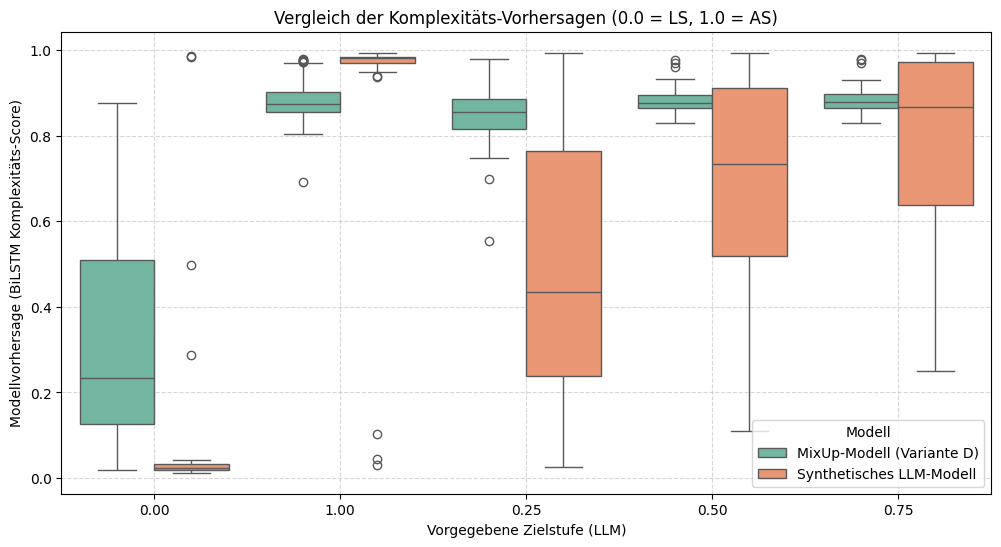

In [ ]:
df_comp = pd.DataFrame({
    "Zielstufe": [f"{t:.2f}" for t in targets_eval] * 2,
    "Vorhergesagter Score": np.concatenate([preds_mixup, preds_synthetic]),
    "Modell": ["MixUp-Modell (Variante D)"] * len(preds_mixup) + ["Synthetisches LLM-Modell"] * len(preds_synthetic)
})

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_comp, x="Zielstufe", y="Vorhergesagter Score", hue="Modell", palette="Set2")
plt.title("Vergleich der Komplexitäts-Vorhersagen (0.0 = LS, 1.0 = AS)")
plt.xlabel("Vorgegebene Zielstufe (LLM)")
plt.ylabel("Modellvorhersage (BiLSTM Komplexitäts-Score)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Modell") 
plt.show()

## 5. Scatterplot & Regressionslinien

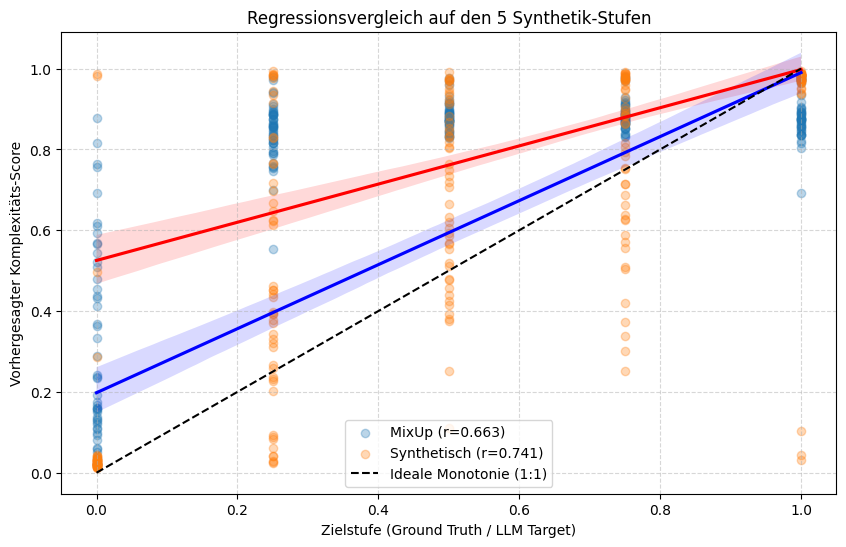

In [12]:
plt.figure(figsize=(10, 6))
sns.regplot(x=targets_eval, y=preds_mixup, label=f"MixUp (r={r_m:.3f})", scatter_kws={"alpha": 0.3}, line_kws={"color": "red"})
sns.regplot(x=targets_eval, y=preds_synthetic, label=f"Synthetisch (r={r_s:.3f})", scatter_kws={"alpha": 0.3}, line_kws={"color": "blue"})
plt.plot([0, 1], [0, 1], "k--", label="Ideale Monotonie (1:1)")
plt.title("Regressionsvergleich auf den 5 Synthetik-Stufen")
plt.xlabel("Zielstufe (Ground Truth / LLM Target)")
plt.ylabel("Vorhergesagter Komplexitäts-Score")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()